<a href="https://colab.research.google.com/github/hyeongjin8744/26-2-DIP-202304391/blob/main/HW/HW01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

- day015 및 day015를 day000에 registration한 파일을 각각 불러오기.
- day000을 포함하여 세 ct영상데이터의 동일한 단면을 display하여 비교하기.

In [ ]:
ct_FU = nib.load('/volume-covid19-A-0700_day015.nii.gz').get_fdata()
ct_FU_reg = nib.load('/volume-covid19-A-0700_day015-reg_to_day000.nii.gz').get_fdata()

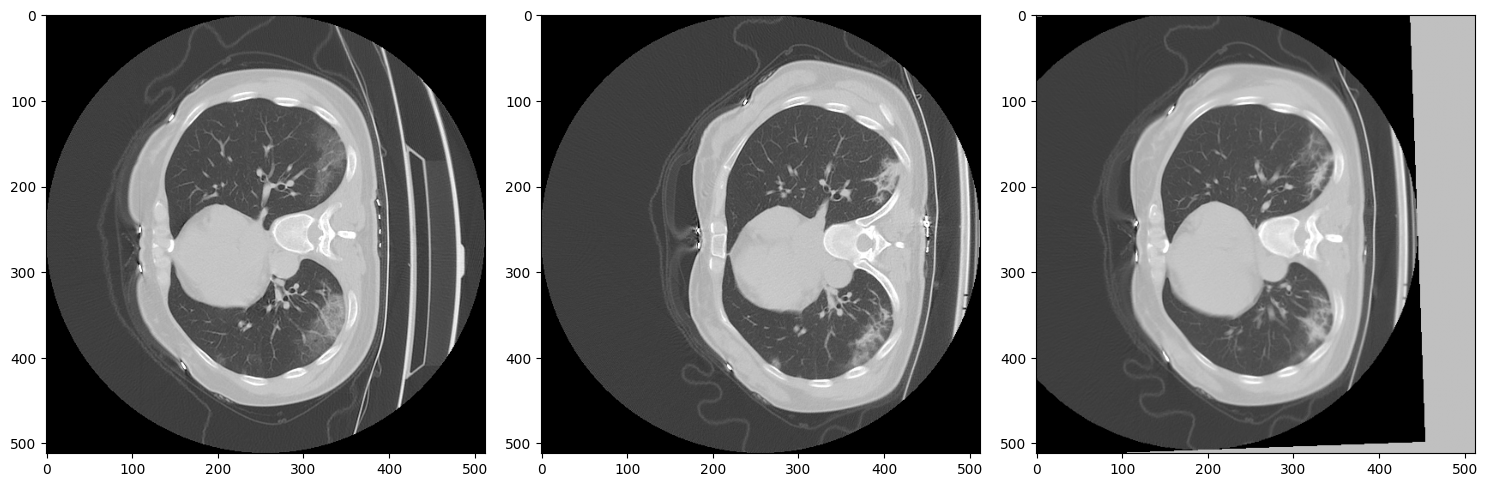

In [ ]:
plt.figure(figsize=(15,5))
plt.subplot(131)
plt.imshow(ct_base[:,:,30],vmin=-1500,vmax=500,cmap='gray')
plt.subplot(132)
plt.imshow(ct_FU[:,:,30],vmin=-1500,vmax=500,cmap='gray')
plt.subplot(133)
plt.imshow(ct_FU_reg[:,:,30],vmin=-1500,vmax=500,cmap='gray')
plt.tight_layout()
plt.show()

### Exercise 1.
- 아래의 예는 local histogram equalization을 수행한다.
- 적절한 neighborhood size N을 찾아서 숨겨진 기호들을 모두 확인해보자.
- plt.imshow의 vim, vmax를 수정하여서도 숨겨진 기호들을 확인할 수 있으나, 본 실습에서는 vmax=255로 고정하여 histogram processing을 통해 숨겨진 기호들을 확인하자.

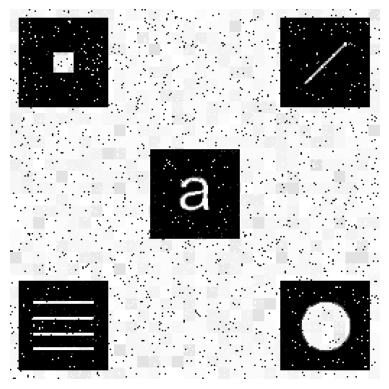

In [ ]:
N = 8
f_eq_local = np.zeros_like(f)

for x in range(0, f.shape[0], N):
    for y in range(0, f.shape[1], N):
        block = f[x:x+N, y:y+N]

        # 밝기가 모두 같은 블록은 그대로 사용
        if block.min() == block.max():
            f_eq_local[x:x+N, y:y+N] = block
        else:
            f_eq_local[x:x+N, y:y+N] = histogram_equalization(block)

plt.imshow(f_eq_local, vmin=0, vmax=255, cmap='gray')
plt.axis('off')
plt.show()

### Exercise 2.
- 직접 찍은 사진을 grayscale image로 불러와서, kernel size를 3x3, 7x7, 15x15, 30x30 으로 늘려가며 box kernel을 정의하여 LPF를 진행한 결과를 출력하고 kernel size에 따른 연산시간의 차이를 확인하자.

In [ ]:
f = io.imread('/content/drive/MyDrive/cat2.jpg',as_gray=True)
print(f.shape,f.dtype)

(1496, 989) float64


In [ ]:
import time

computation time =  0.13355565071105957  sec


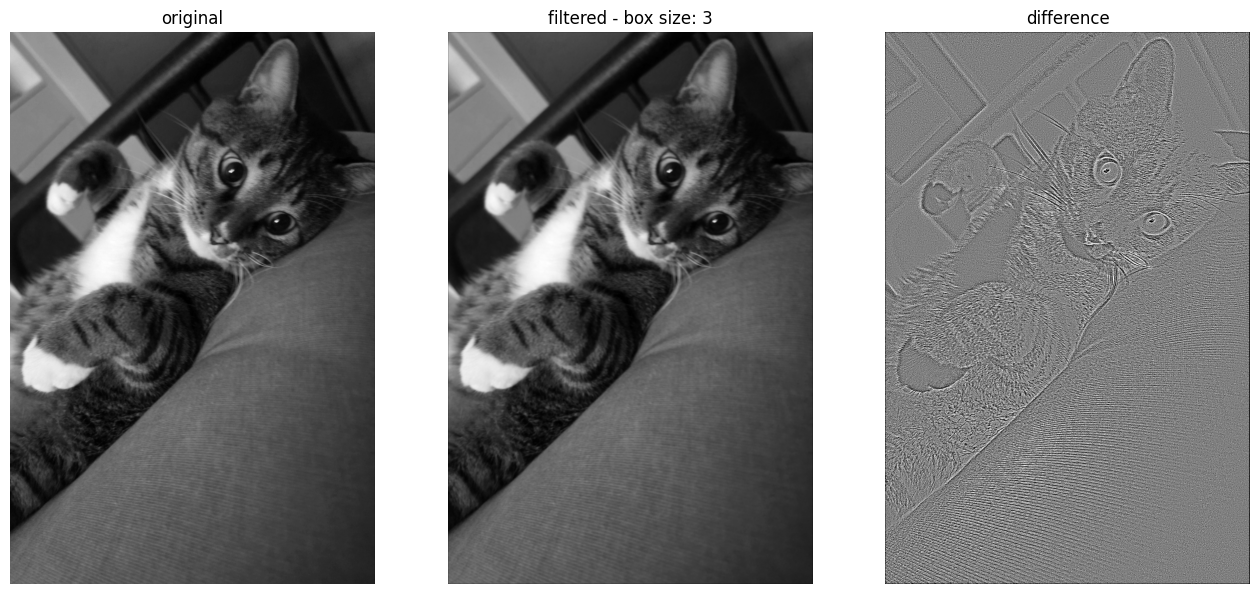

computation time =  0.2138371467590332  sec


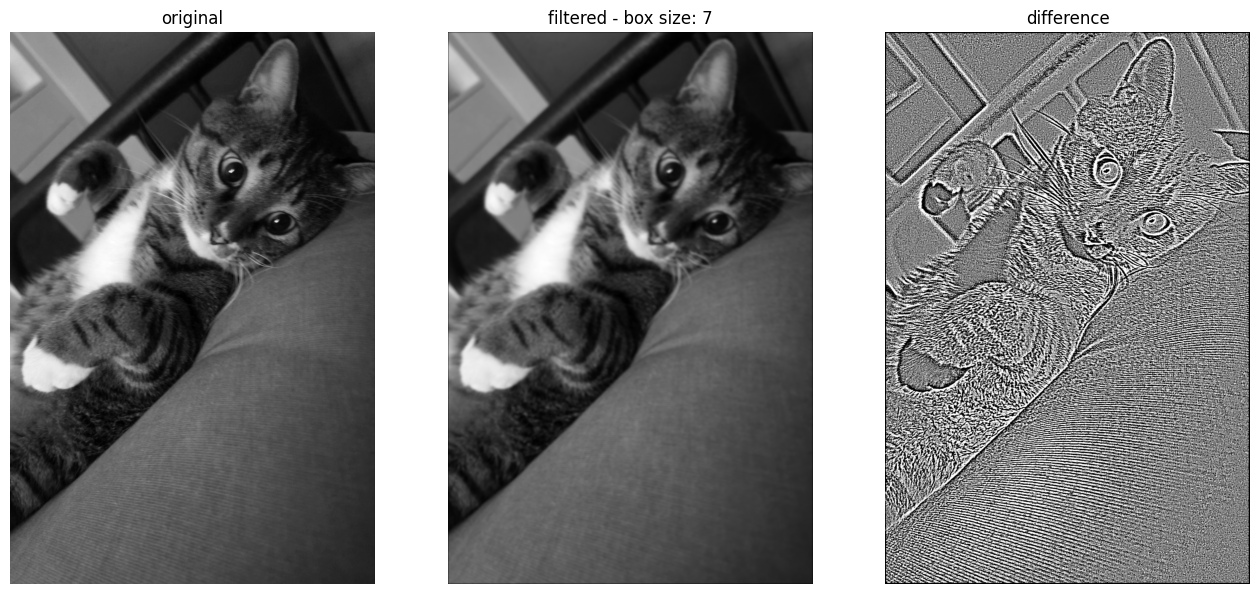

computation time =  1.5191619396209717  sec


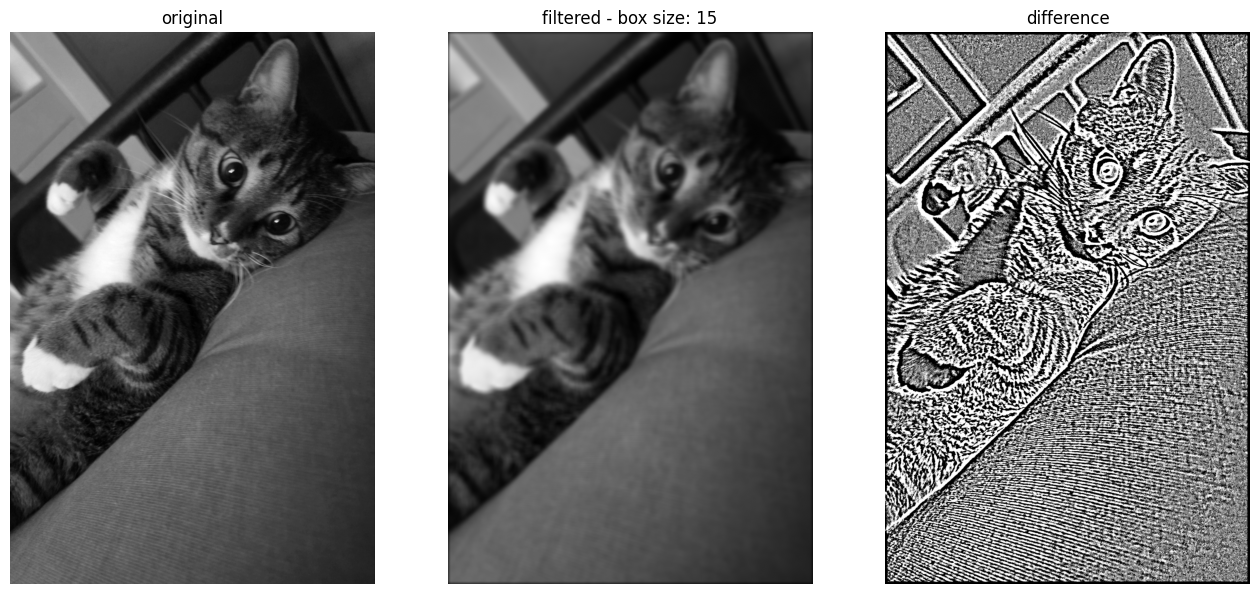

computation time =  2.8566839694976807  sec


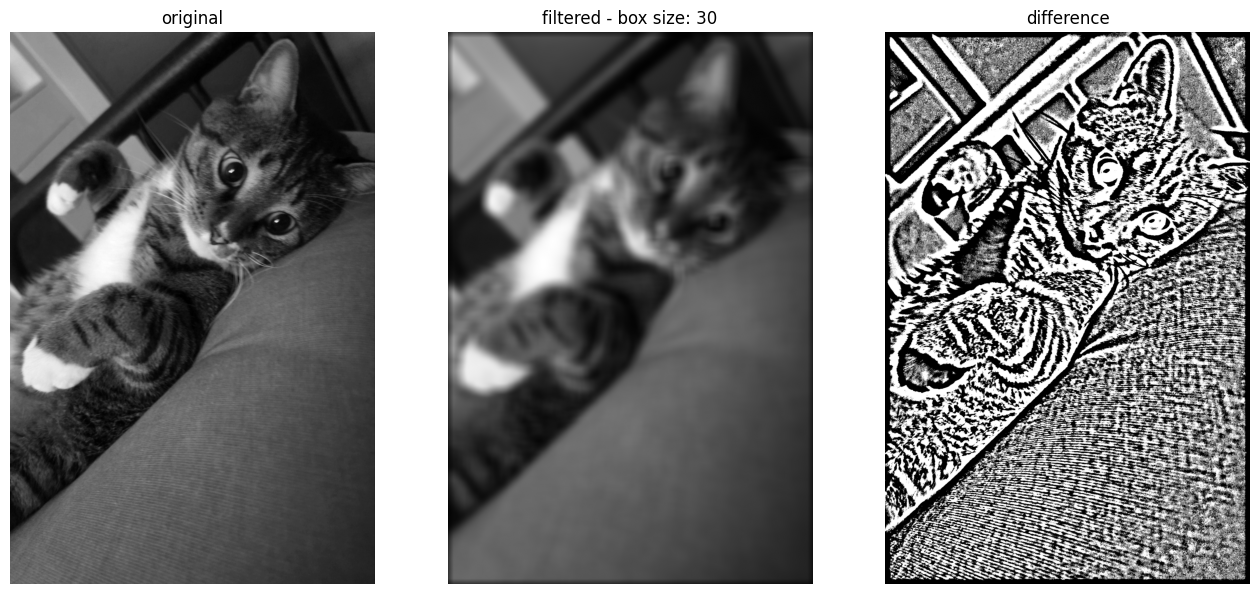

In [ ]:
for N in np.array([3,7,15,30]):
  wb = np.ones((N,N))
  wb = wb/np.sum(wb)
  s0 = time.time()
  y_b = signal.convolve2d(f,wb,mode='same')
  compu_time=time.time() - s0
  print('computation time = ', compu_time,' sec')
  plt.figure(figsize=(16,9))
  plt.subplot(1,3,1)
  plt.imshow(f,cmap='gray')
  plt.axis('off')
  plt.title('original')
  plt.subplot(1,3,2)
  plt.imshow(y_b,cmap='gray')
  plt.axis('off')
  plt.title(f'filtered - box size: {N}')
  plt.subplot(1,3,3)
  plt.imshow(y_b-f,cmap='gray',vmin=-.01,vmax=.01)
  plt.axis('off')
  plt.title('difference')
  plt.show()

### Exercise 3.
- highpass filtering의 결과를 활용하여 blurred image를 sharp하게 개선시켜 보자.
- 자신만의 blurred image를 가져와서, Laplacian kernel을 통한 highpass filtering을 진행하고 이를 이용하여 원본영상의 sharpness를 증대시켜보자.
- w 및 c를 적절하게 변화시켜 가면서 결과를 확인하자.

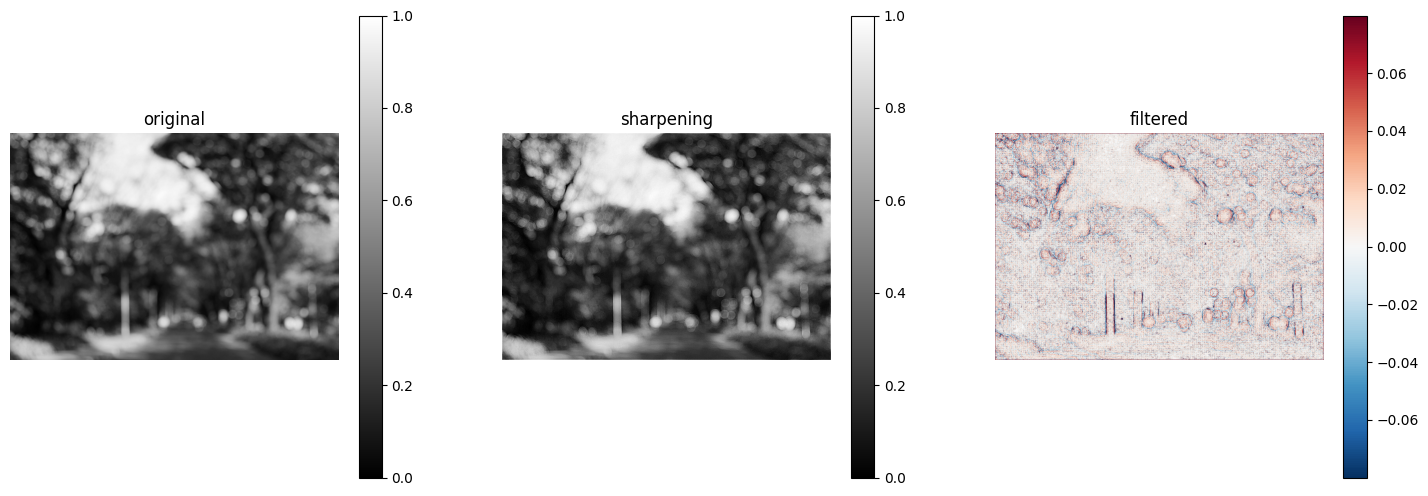

In [ ]:
f = io.imread('/content/drive/MyDrive/tree.jpg', as_gray=True)
#f = io.imread('https://www.magnific.com/free-photo/road-going-through-park_2769589.htm#fromView=keyword&page=1&position=17&uuid=3063f24b-310f-4d6f-9bb7-6f2eb2f097ed&track=ais_hybrid&query=Blur+background+outside',as_gray=True)[::2,::2]

w = np.array([[-1,-1,-1],[-1,8.,-1],[-1,-1,-1]])
y = signal.convolve2d(f,w,mode='same')
c = 1.0
g = f + c*y
plt.figure(figsize=(18,6))
plt.subplot(131)
plt.imshow(f,cmap='gray',vmin=0,vmax=1)
plt.colorbar()
plt.axis('off')
plt.title('original')
plt.subplot(132)
plt.imshow(g,cmap='gray',vmin=0,vmax=1)
plt.colorbar()
plt.axis('off')
plt.title('sharpening')
plt.subplot(133)
plt.imshow(y,cmap='RdBu_r',vmin=-np.percentile(np.abs(y[1:-1,1:-1]),99),vmax=np.percentile(np.abs(y[1:-1,1:-1]),99))
plt.colorbar()
plt.axis('off')
plt.title('filtered')
plt.show()